<a href="https://colab.research.google.com/github/YAGNAMANYAM/Machine-Learning/blob/main/Cognifyz_Task4_Location_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Dataset .csv to Dataset .csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("Dataset .csv")
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
print(data.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [6]:
data.fillna(data.mean(numeric_only=True), inplace=True)

for col in data.select_dtypes(include='object'):
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_10850/3708418033.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [7]:
!pip install folium

In [8]:
import folium

In [9]:
# Center map
map_center = [data['Latitude'].mean(), data['Longitude'].mean()]

restaurant_map = folium.Map(location=map_center, zoom_start=5)

# Add markers (limit for speed)
for i in range(100):
    folium.Marker(
        [data.iloc[i]['Latitude'], data.iloc[i]['Longitude']],
        popup=data.iloc[i]['Restaurant Name']
    ).add_to(restaurant_map)

restaurant_map

In [10]:
city_counts = data['City'].value_counts()

print(city_counts.head(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


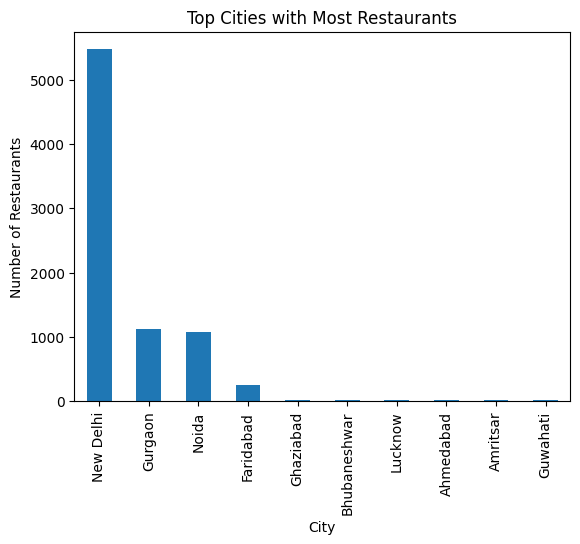

In [11]:
city_counts.head(10).plot(kind='bar')
plt.title("Top Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()

In [12]:
avg_rating = data.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print(avg_rating.head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


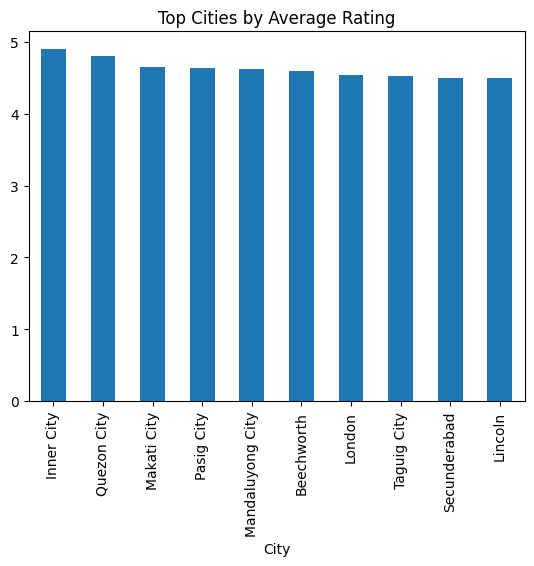

In [13]:
avg_rating.head(10).plot(kind='bar')
plt.title("Top Cities by Average Rating")
plt.show()

In [14]:
price_range = data.groupby('City')['Price range'].mean().sort_values(ascending=False)

print(price_range.head(10))

City
Panchkula           4.000000
Vineland Station    4.000000
Paynesville         4.000000
Johannesburg        4.000000
Inner City          4.000000
Pasay City          4.000000
Princeton           4.000000
Sandton             3.818182
Mandaluyong City    3.750000
Pretoria            3.700000
Name: Price range, dtype: float64


In [15]:
cuisine_counts = data['Cuisines'].value_counts()

print(cuisine_counts.head(10))

Cuisines
North Indian                      945
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


Objective:
To perform geographical analysis of restaurants based on location.

Data Visualization:
Restaurant locations were plotted using latitude and longitude on a map.

City Analysis:
Restaurants were grouped by city to identify areas with high concentration.

Findings:

Certain cities have higher restaurant density
Popular cities show higher average ratings
Price range varies across cities

Cuisine Insights:
Some cuisines are more popular in specific locations.

Conclusion:
Location plays an important role in restaurant distribution, ratings, and pricing patterns.